The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


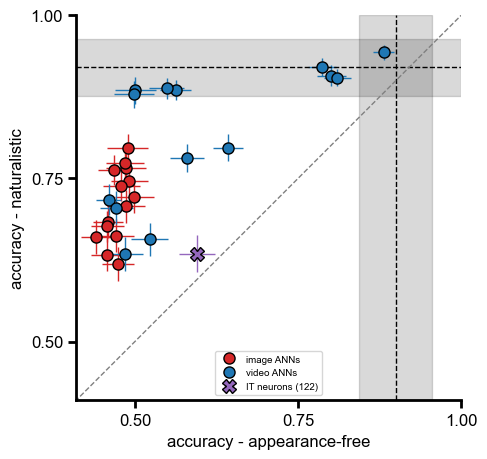

image ANNs RGB mean accuracy: 0.71 ± 0.05
image ANNs AFV mean accuracy: 0.47 ± 0.02
video ANNs RGB mean accuracy: 0.83 ± 0.10
video ANNs AFV mean accuracy: 0.59 ± 0.16
video ANNs RGB vs AFV TtestResult(statistic=np.float64(6.254208423938463), pvalue=np.float64(2.1117977396094047e-05), df=np.int64(14))
sam2
video ANNs RGB mean accuracy: [0.8826468] ± [0.0275542]
video ANNs AFV mean accuracy: [0.2754578] ± [0.0341918]
optic flow
video ANNs RGB mean accuracy: 0.91 ± 0.01
video ANNs AFV mean accuracy: 0.79 ± 0.01
world models
video ANNs RGB mean accuracy: 0.92 ± 0.02
video ANNs AFV mean accuracy: 0.85 ± 0.04


In [6]:
import sys
sys.path.append('../')

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.pyplot import cm
import scipy.stats as stats

from utils.plot_utils import journal_figure_pdf, journal_figure

import scienceplots

plt.style.use(['nature'])

# Define static (image) models with their properties: [type, color, label]
static_models = {
    "images_moving1_alexnet_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:red', 'AlexNet'], 
    "images_moving1_convnext_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:red', 'ConvNeXt'], 
    "images_moving1_densenet121_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:red', 'DenseNet-121'], 
    "images_moving1_efficientnet_b0_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:red', 'EfficientNet-B0'], 
    "images_moving1_hiera_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:red', 'Hiera'], 
    "images_moving1_inception_v3_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:red', 'Inception-V3'], 
    "images_moving1_pnasnet_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:red', 'PNASNet'], 
    "images_moving1_resnet50_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:red', 'ResNet-50'], 
    "images_moving1_resnet50_ssl_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:red', 'ResNet-50-SSL'], 
    "images_moving1_vit_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:red', 'ViT'], 
    "images_moving1_vit_ssl_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:red', 'ViT-SSL'], 
    "images_moving1_nasnet_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:red', 'NASNet'], 
    "images_moving1_rgc_intermediate_features_ff_srp-rgb2afv_1000_10.h5" : ['ri', 'tab:red', 'ConvRNN'],
    "images_moving1_CORnet-S_IT_features_srp-rgb2afv_1000_10.h5" : ['ri', 'tab:red', 'CORnet-S'],
}

# Define dynamic (video) models with their properties: [type, color, label]
dynamic_models = {
    "images_moving1_c2d_r50-blocks.4.res_blocks.5.activation_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'C2D'], 
    "images_moving1_i3d_r50-blocks.5.res_blocks.2.activation_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'I3D'], 
    "images_moving1_x3d_xs-blocks.4.res_blocks.6.activation_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'X3D-XS'], 
    "images_moving1_sam2.1_hiera_b+-256-memory_attention-2_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'SAM2'], 
    "images_moving1_slow_r50_ssv2-blocks.4.res_blocks.2.activation_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'SlowR50-ssv2'], 
    "images_moving1_slow_r50-blocks.4.res_blocks.2.activation_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'SlowR50'], 
    "images_moving1_timesformer_ssv2-timesformer.encoder.layer.8_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'TimesFormer-ssv2'], 
    "images_moving1_timesformer-timesformer.encoder.layer.11_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'TimesFormer'], 
    "images_moving1_videomamba_ssv2-layers.10.mixer_features_srp-rgb2afv_1000_10.h5"  : ['d', 'tab:blue', 'VideoMamba-ssv2'], 
    "images_moving1_videomamba-layers.10.mixer_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'VideoMamba'], 
    "images_moving1_videomae-videomae.encoder.layer.2_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'VideoMAE'], 
    "images_moving1_matnet_fusion_type_gated-layer4,sensor_fusion_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'MatNet'],
    "images_moving1_twostream_deeplabv3plus_resnet101_davis-layer4,sensor_fusion_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'FusionSeg'],
    "images_moving1_vjepa2-encoder.layer.16.mlp.fc2_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'V-JEPA2l'],
    "images_moving1_vjepa2g-encoder.layer.39.mlp.fc2_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'V-JEPA2g'],
}

# Path to folder containing model classification scores
scores_path_n = '../../scores/figure4'
scores_path = '../../scores/figure4'

# Combine static and dynamic models
models = {**static_models, **dynamic_models}

# Initialize lists to store results for RGB->AFV decoding task
values_rgb2afv_rgb = []
errors_rgb2afv_rgb = []
values_rgb2afv_afv = []
errors_rgb2afv_afv = []

vid_values_rgb2afv_rgb = []
vid_values_rgb2afv_afv = []

# Initialize lists to store results for AFV->RGB decoding task
values_afv2rgb_rgb = []
errors_afv2rgb_rgb = []
values_afv2rgb_afv = []
errors_afv2rgb_afv = []

vid_values_afv2rgb_rgb = []
vid_values_afv2rgb_afv = []

# ============================================================================
# PROCESS RGB->AFV DECODING RESULTS FOR EACH MODEL
# ============================================================================
methods_names = list(models.keys())
for name in methods_names:
    # Load RGB->AFV decoding results
    file_rgb_rgb2afv = h5py.File(f'{scores_path}/{name}/decode_obj_dir_linear_rgb2afv.h5', 'r')
    #print(list(file_rgb_rgb2afv.keys()))
    # Process i1 scores for original (RGB) features
    i1_per_time_rgb2afv_rgb = np.array(file_rgb_rgb2afv[f'i1_all_rgb'])
    #print(name, np.nanmean(i1_per_time_rgb2afv_rgb))
    i1_per_time_rgb2afv_rgb = np.nanmean(i1_per_time_rgb2afv_rgb, axis=-1)
    i1_per_time_rgb2afv_rgb = np.nanmean(i1_per_time_rgb2afv_rgb, axis=0)
    
    # Find best performing video and extract its scores
    i1_per_time_rgb2afv_rgb_m = np.nanmean(i1_per_time_rgb2afv_rgb, axis=-1)
    max_id = np.nanargmax(i1_per_time_rgb2afv_rgb_m)
    i1_per_time_rgb2afv_rgb = i1_per_time_rgb2afv_rgb[max_id]

    # Process i1 scores for AFV features
    i1_per_time_rgb2afv_afv = np.array(file_rgb_rgb2afv[f'i1_all_afv'])
    i1_per_time_rgb2afv_afv = np.nanmean(i1_per_time_rgb2afv_afv, axis=-1)
    i1_per_time_rgb2afv_afv = np.nanmean(i1_per_time_rgb2afv_afv, axis=0)

    # Find best performing video and extract its scores
    i1_per_time_rgb2afv_afv_m = np.nanmean(i1_per_time_rgb2afv_afv, axis=-1)
    #max_id = np.nanargmax(i1_per_time_rgb2afv_afv_m)
    i1_per_time_rgb2afv_afv = i1_per_time_rgb2afv_afv[max_id]
    
    

    # Calculate mean and standard error for RGB->AFV task (original features)
    i1_per_time_rgb2afv_rgb_mean = np.nanmean(i1_per_time_rgb2afv_rgb, axis=0)
    i1_per_time_rgb2afv_rgb_se = np.nanstd(i1_per_time_rgb2afv_rgb, axis=0) / np.sqrt(i1_per_time_rgb2afv_rgb.shape[0])

    values_rgb2afv_rgb.append(i1_per_time_rgb2afv_rgb_mean)
    errors_rgb2afv_rgb.append(i1_per_time_rgb2afv_rgb_se)

    # Calculate mean and standard error for RGB->AFV task (AFV features)
    i1_per_time_rgb2afv_afv_mean = np.nanmean(i1_per_time_rgb2afv_afv, axis=0)
    i1_per_time_rgb2afv_afv_se = np.nanstd(i1_per_time_rgb2afv_afv, axis=0) / np.sqrt(i1_per_time_rgb2afv_afv.shape[0])

    values_rgb2afv_afv.append(i1_per_time_rgb2afv_afv_mean)
    errors_rgb2afv_afv.append(i1_per_time_rgb2afv_afv_se)

    vid_values_rgb2afv_rgb.append(i1_per_time_rgb2afv_rgb)  
    vid_values_rgb2afv_afv.append(i1_per_time_rgb2afv_afv)


# ============================================================================
# PROCESS IT NEURON DECODING RESULTS (RGB->AFV)
# ============================================================================
file_rgb_rgb2afv = h5py.File(f'{scores_path_n}/IT_neurons/decode_IT_obj_dir_linear_rgb2afv.h5', 'r')
accuracy_per_time_rgb2afv_rgb = np.array(file_rgb_rgb2afv['i1_orig_all'])
accuracy_per_time_rgb2afv_rgb = np.nanmean(accuracy_per_time_rgb2afv_rgb, axis=0)

accuracy_per_time_rgb2afv_afv = np.array(file_rgb_rgb2afv['i1_afv_all'])
accuracy_per_time_rgb2afv_afv = np.nanmean(accuracy_per_time_rgb2afv_afv, axis=0)

# Extract best video and compute statistics for RGB features
accuracy_per_time_rgb2afv_rgb_m = np.nanmean(accuracy_per_time_rgb2afv_rgb, axis=-1)
best_idx = np.argmax(accuracy_per_time_rgb2afv_rgb_m)
accuracy_per_time_rgb2afv_rgb_vid = accuracy_per_time_rgb2afv_rgb[best_idx]
accuracy_per_time_rgb2afv_rgb_m = np.nanmean(accuracy_per_time_rgb2afv_rgb[best_idx])
accuracy_per_time_rgb2afv_rgb_se = np.nanstd(accuracy_per_time_rgb2afv_rgb[best_idx]) / np.sqrt(accuracy_per_time_rgb2afv_rgb.shape[1])

# Extract best video and compute statistics for AFV features
accuracy_per_time_rgb2afv_afv_m = np.nanmean(accuracy_per_time_rgb2afv_afv, axis=-1)
#best_idx = np.argmax(accuracy_per_time_rgb2afv_afv_m)
accuracy_per_time_rgb2afv_afv_vid = accuracy_per_time_rgb2afv_afv[best_idx]
accuracy_per_time_rgb2afv_afv_m = np.nanmean(accuracy_per_time_rgb2afv_afv[best_idx])
accuracy_per_time_rgb2afv_afv_se = np.nanstd(accuracy_per_time_rgb2afv_afv[best_idx]) / np.sqrt(accuracy_per_time_rgb2afv_afv.shape[1])

# Human accuracy benchmarks
human_accouracy_mean = [0.92, 0.9]
human_accouracy_std = [0.044, 0.056]


plt.figure(figsize=(5, 5))

x = np.array(values_rgb2afv_afv)
y = np.array(values_rgb2afv_rgb)

xerr = np.array(errors_rgb2afv_afv)
yerr = np.array(errors_rgb2afv_rgb)

image_mask = np.array([models[name][0] in ['f', 'ri'] for name in methods_names], dtype=bool)
video_mask = np.array([models[name][0] in ['d', 'rv'] for name in methods_names], dtype=bool)

plt.errorbar(x[image_mask], y[image_mask],
             xerr=xerr[image_mask], yerr=yerr[image_mask],
             fmt='o', color='tab:red', markeredgecolor='black', markersize=8,
             capsize=0, label='image ANNs',)

plt.errorbar(x[video_mask], y[video_mask],
             xerr=xerr[video_mask], yerr=yerr[video_mask],
             fmt='o', color='tab:blue', markeredgecolor='black', markersize=8,
             capsize=0, label='video ANNs',)

plt.errorbar(accuracy_per_time_rgb2afv_afv_m, accuracy_per_time_rgb2afv_rgb_m,
             xerr=accuracy_per_time_rgb2afv_afv_se, yerr=accuracy_per_time_rgb2afv_rgb_se,
             fmt='X', color='tab:purple', markeredgecolor='black', markersize=10,
             capsize=0, label='IT neurons (122)')


# Human accuracy benchmarks
human_accouracy_mean = [0.92, 0.9]
human_accouracy_std = [0.044, 0.056]
plt.axhline(human_accouracy_mean[0], color='black', linestyle='--', linewidth=1)
plt.axhspan(human_accouracy_mean[0] - human_accouracy_std[0], human_accouracy_mean[0] + human_accouracy_std[0], color='black', alpha=0.15)

plt.axvline(human_accouracy_mean[1], color='black', linestyle='--', linewidth=1)
plt.axvspan(human_accouracy_mean[1] - human_accouracy_std[1], human_accouracy_mean[1] + human_accouracy_std[1], color='black', alpha=0.15)


plt.plot([0.40, 1.0], [0.40, 1.0], color='gray', linestyle='--', linewidth=1)

plt.xlabel('accuracy - appearance-free', fontsize=12)
plt.ylabel('accuracy - naturalistic', fontsize=12)
plt.xlim(0.41, 1.0)
plt.ylim(0.41, 1.0)
plt.xticks(np.arange(0.5, 1.01, 0.25))
plt.yticks(np.arange(0.5, 1.01, 0.25))
plt.legend()

journal_figure(do_save=True, filename=f'../../plots/figure4_decode_obj_dir_linear_rgb2afv-scatterplot.eps')
journal_figure_pdf(do_save=True, filename=f'../../plots/figure4_decode_obj_dir_linear_rgb2afv-scatterplot.pdf')
    
plt.show()

print(f'image ANNs RGB mean accuracy: {np.nanmean(y[image_mask]):.2f} ± {np.nanstd(y[image_mask]):.2f}')
print(f'image ANNs AFV mean accuracy: {np.nanmean(x[image_mask]):.2f} ± {np.nanstd(x[image_mask]):.2f}')
print(f'video ANNs RGB mean accuracy: {np.nanmean(y[video_mask]):.2f} ± {np.nanstd(y[video_mask]):.2f}')
print(f'video ANNs AFV mean accuracy: {np.nanmean(x[video_mask]):.2f} ± {np.nanstd(x[video_mask]):.2f}')

print('video ANNs RGB vs AFV', stats.ttest_rel(y[video_mask], x[video_mask]))

for nn, idxs in [('sam2', [3]), ('optic flow', [-3, -4]), ('world models', [-1, -2])]:
    print(nn)
    if len(idxs) == 1:
        print(f'video ANNs RGB mean accuracy: {y[video_mask][idxs]} ± {yerr[video_mask][idxs]}')
        print(f'video ANNs AFV mean accuracy: {x[video_mask][idxs]} ± {xerr[video_mask][idxs]}')
    else:
        print(f'video ANNs RGB mean accuracy: {np.nanmean(y[video_mask][idxs]):.2f} ± {np.nanstd(y[video_mask][idxs]):.2f}')
        print(f'video ANNs AFV mean accuracy: {np.nanmean(x[video_mask][idxs]):.2f} ± {np.nanstd(x[video_mask][idxs]):.2f}')

